# H4 — Non-aided Task Performance (F1 / F2 / F3)

> **H4 (saved reading time is redeployed; supporting).** Because contrastive
> framing and an actionable cue make the same information easier to process under
> load, attention freed from reading the explanation panel is redeployed to the
> **non-aided tasks**. Participants therefore achieve **higher performance on
> communications and resource management** under the contrastive forms
> **F2 / F3** than under the verbose form **F1**.

**Design**

| Role | Variable | Detail |
|------|----------|--------|
| Independent variable | Explanation **form** | F1 verbose · F2 contrastive · F3 contrastive + actionable. **Within-subjects** — each participant sees all three (Latin-square counterbalanced). |
| Primary DV (resman) | **RMSD from target** & **% time in tolerance** | Deviation of the two tank levels from the 2500 target. Lower RMSD / higher % = better. |
| Primary DV (comms) | **Response accuracy** & **response time on hits** | Hits on own-call-sign requests; RT (ms) from end-of-call to a validated response. Higher accuracy / lower RT = better. |

Both DVs are read directly from the continuous OpenMATB platform log — no
questionnaire is involved in H4.

## How performance is measured (literature)

**Resource management.** Two depleting tanks (A, B) must be held near a target of
2500 units. Performance is the **root-mean-square deviation (RMSD)** of tank level
from target, the **mean absolute deviation (MAD)**, and the **proportion of time
within tolerance** (±500 → 2000–3000). These are the standard MATB resource-
management readouts:
- Cegarra, J., Valéry, B., Avril, E., Calmettes, C., & Navarro, J. (2020).
  *OpenMATB: A Multi-Attribute Task Battery…* Behavior Research Methods, 52, 1980–1990.
- Santiago-Espada, Y., Myer, R. R., Latorella, K. A., & Comstock, J. R. (2011).
  *The Multi-Attribute Task Battery II (MATB-II) Software… User's Guide.* NASA/TM-2011-217164.
- Comstock, J. R., & Arnegard, R. J. (1992). *The Multi-Attribute Task Battery…* NASA TM-104174.

**Communications.** Respond to own-call-sign radio requests (set the named radio to
the requested frequency), ignore distractor call signs. Scored as **response
accuracy** and **response time** within a signal-detection framing
(hit / miss / false alarm; OpenMATB also distinguishes wrong-radio / wrong-frequency
errors). Response time is the latency from end-of-call to a validated response, in
milliseconds, reported on hits only.
- Cegarra et al. (2020), as above.
- Green, D. M., & Swets, J. A. (1966). *Signal Detection Theory and Psychophysics.*
  Wiley. (hit / miss / false-alarm framing.)

**Descriptive statistics and visualisations**

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matb_analysis.aggregate import build_metrics_table
from matb_analysis.discovery import find_study_sessions, DEFAULT_SESSIONS_DIR
from matb_analysis.validation import validate_sessions

sns.set_theme(style="whitegrid")
FORM_ORDER = ["F1", "F2", "F3"]
FORM_LABELS = {"F1": "F1\nverbose", "F2": "F2\ncontrastive", "F3": "F3\n+actionable"}
OUT = Path.cwd().parent / "outputs"
OUT.mkdir(exist_ok=True)

# Human-readable column headers with units and direction-of-better (down arrow =
# lower is better, up arrow = higher is better). Used to relabel the descriptive
# tables below so each header is self-explanatory.
COL_LABELS = {
    # resource management
    "rmsd_mean": "RMSD from target [units] (down = better)",
    "pct_in_tolerance_mean": "Time in tolerance [%] (up = better)",
    "mad_a": "MAD tank A [units] (down = better)",
    "mad_b": "MAD tank B [units] (down = better)",
    "n_excursions": "Out-of-tolerance excursions [count] (down = better)",
    # communications
    "accuracy": "Accuracy [hits / signal trials] (up = better)",
    "miss_rate": "Miss rate [misses / signal trials] (down = better)",
    "mean_rt_hit": "Response time on hits [ms] (down = better)",
    "fa_count": "False alarms [count] (down = better)",
    "mean_abs_freq_dev": "Abs. frequency-setting error [MHz] (down = better)",
    "n_signal": "Signal trials [count]",
    # bookkeeping
    "participant": "Participant",
    "form": "Form",
    "block": "Block",
}

## 1. Load the sessions and build the H4 metrics table

`find_study_sessions()` reads every study session under `session_logs/`. Each
session contributes three rows (one per form). The resource-management and
communications metrics are produced by `build_metrics_table()` directly from the
continuous platform log.

In [2]:
sessions = find_study_sessions()
print(f"Reading logs from: {DEFAULT_SESSIONS_DIR}")
print(f"Discovered {len(sessions)} study session(s).")

table = build_metrics_table(sessions)
h4_cols = ["rmsd_mean", "pct_in_tolerance_mean", "accuracy", "mean_rt_hit", "fa_count"]
preview = (table[["participant", "form", "block"] + h4_cols]
           .sort_values(["participant", "form"]).reset_index(drop=True))
preview.rename(columns=COL_LABELS)

Reading logs from: C:\Projects\HumanCenteredAI\Analysis\session_logs
Discovered 12 study session(s).


,Participant,Form,Block,RMSD from target [units] (down = better),Time in tolerance [%] (up = better),Accuracy [hits / signal trials] (up = better),Response time on hits [ms] (down = better),False alarms [count] (down = better)
0,P01,F1,A,132.511810,92.715232,0.500000,9760.000000,0
1,P01,F2,B,134.287662,89.666667,1.000000,7653.333333,0
2,P01,F3,C,100.069004,95.033113,0.833333,7440.000000,1
3,P02,F1,A,193.205581,79.139073,0.200000,10640.000000,0
4,P02,F2,C,129.681753,89.666667,1.000000,9973.333333,0
5,P02,F3,B,198.600959,81.666667,0.714286,11424.000000,0
6,P03,F1,B,139.893802,92.333333,0.714286,8160.000000,0
7,P03,F2,A,151.451979,91.390728,0.625000,7536.000000,0
8,P03,F3,C,120.834243,94.701987,0.857143,7853.333333,0
9,P04,F1,C,207.191118,85.099338,0.714286,8688.000000,0


### 1b. Sanity check: design realised as intended

Each session is cross-checked against the Latin-square design (form ↔ block order,
panel form vs. briefing). Any `ok = False` row must be resolved before trusting
that session's numbers.

In [3]:
report = validate_sessions(sessions)
n_bad = int((~report["ok"]).sum()) if not report.empty else 0
print(f"{len(report)} session(s) validated; {n_bad} with design issues.")

n_signal = table.groupby("form")["n_signal"].agg(["min", "max"]).reindex(FORM_ORDER)
print("\nNumber of communications signal trials per block, by form:")
print(n_signal.to_string())

12 session(s) validated; 0 with design issues.

Number of communications signal trials per block, by form:
      min  max
form          
F1      6   10
F2      6    8
F3      6    8


## 2. Resource management by form

RMSD from the 2500 target and mean absolute deviation (both **lower = better**),
and the percent of time the tanks stayed within tolerance (**higher = better**).
With one block per form per participant the SD is undefined until N grows.

In [4]:
def describe(df, col):
    g = df.groupby("form")[col]
    out = pd.DataFrame({
        "n_blocks": g.size(),
        "mean": g.mean(),
        "sd": g.std(),
        "median": g.median(),
        "min": g.min(),
        "max": g.max(),
    }).reindex(FORM_ORDER).round(3)
    return out

resman_desc = (table.groupby("form")[["rmsd_mean", "pct_in_tolerance_mean",
                                       "mad_a", "mad_b", "n_excursions"]]
                    .agg(["mean", "median", "std"])
                    .reindex(FORM_ORDER)
                    .round(2))
resman_desc.rename(columns=COL_LABELS)

RMSD from target [units] (down = better)                  \
                                         mean  median     std   
form                                                            
F1                                     767.51  499.08  662.63   
F2                                     744.06  406.46  669.08   
F3                                     769.29  443.67  735.62   

     Time in tolerance [%] (up = better)                \
                                    mean median    std   
form                                                     
F1                                 44.30  38.83  35.51   
F2                                 46.58  45.28  37.36   
F3                                 50.03  50.67  39.44   

     MAD tank A [units] (down = better)                  \
                                   mean  median     std   
form                                                      
F1                               608.52  460.88  536.66   
F2                               591.02  409.79  545.24   
F3                               626.78  371.40  603.06   

     MAD tank B [units] (down = better)                  \
                                   mean  median     std   
form                                                      
F1                               731.66  385.00  687.11   
F2                               726.91  332.97  680.57   
F3                               727.29  369.68  737.93   

     Out-of-tolerance excursions [count] (down = better)               
                                                    mean median   std  
form                                                                   
F1                                                 2.50     2.0  1.38  
F2                                                 3.67     3.5  1.61  
F3                                                 3.17     3.0  1.47

**Figure 1 — resource-management performance by form.** Box = median and
interquartile range; whiskers = range; each dot is one block. H4 predicts F2/F3 to
sit **below** F1 on RMSD (less deviation) and **above** F1 on % in tolerance.

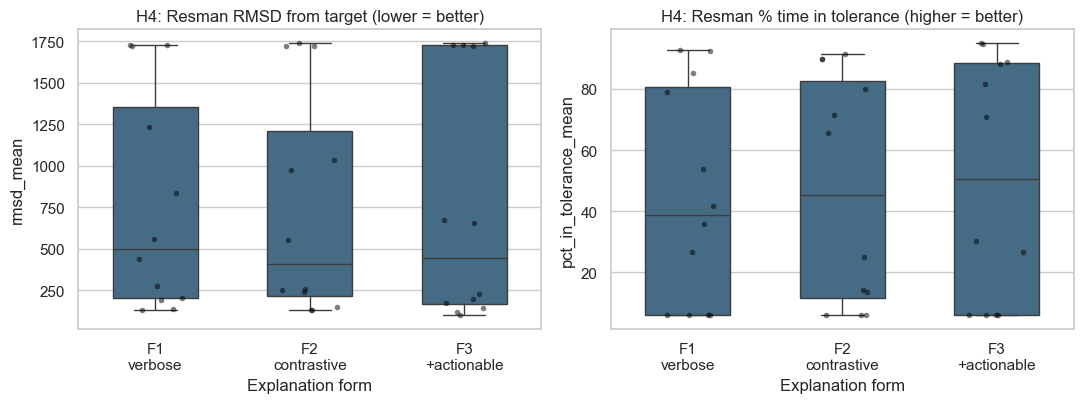

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, col, title, better in zip(
    axes,
    ["rmsd_mean", "pct_in_tolerance_mean"],
    ["Resman RMSD from target", "Resman % time in tolerance"],
    ["lower = better", "higher = better"],
):
    sns.boxplot(data=table, x="form", y=col, order=FORM_ORDER,
                color="#3b6e8f", width=0.55, ax=ax)
    sns.stripplot(data=table, x="form", y=col, order=FORM_ORDER,
                  color="black", alpha=0.5, size=4, jitter=0.18, ax=ax)
    ax.set_xlabel("Explanation form")
    ax.set_xticks(range(len(FORM_ORDER)))
    ax.set_xticklabels([FORM_LABELS[f] for f in FORM_ORDER])
    ax.set_title(f"H4: {title} ({better})")
fig.tight_layout()
fig.savefig(OUT / "h4_resman_by_form.png", dpi=150)
plt.show()

## 3. Communications by form

Response **accuracy** (hits / signal trials, higher = better), **response time on
hits** in ms (lower = better), false-alarm count, and the absolute
frequency-setting error on responses.

In [6]:
comms_desc = (table.groupby("form")[["accuracy", "miss_rate", "mean_rt_hit",
                                      "fa_count", "mean_abs_freq_dev", "n_signal"]]
                   .agg(["mean", "median", "std"])
                   .reindex(FORM_ORDER)
                   .round(3))
comms_desc.rename(columns=COL_LABELS)

Accuracy [hits / signal trials] (up = better)                \
                                              mean median    std   
form                                                               
F1                                           0.382  0.500  0.322   
F2                                           0.550  0.670  0.429   
F3                                           0.502  0.598  0.392   

     Miss rate [misses / signal trials] (down = better)                \
                                                   mean median    std   
form                                                                    
F1                                                0.506  0.312  0.378   
F2                                                0.416  0.208  0.441   
F3                                                0.451  0.268  0.421   

     Response time on hits [ms] (down = better)                      \
                                           mean    median       std   
form                                                                  
F1                                     9304.000  9494.000  1031.953   
F2                                     9064.500  8878.000  1218.409   
F3                                     9124.167  9041.333  1664.922   

     False alarms [count] (down = better)                \
                                     mean median    std   
form                                                      
F1                                  0.333    0.0  0.651   
F2                                  0.250    0.0  0.452   
F3                                  0.833    0.0  1.403   

     Abs. frequency-setting error [MHz] (down = better)                \
                                                   mean median    std   
form                                                                    
F1                                                0.822  0.343  0.984   
F2                                                0.120  0.000  0.242   
F3                                                0.466  0.000  1.234   

     Signal trials [count]                
                      mean median    std  
form                                      
F1                   7.333    7.0  1.155  
F2                   6.500    6.0  0.674  
F3                   6.667    7.0  0.651

**Figure 2 — communications performance by form.** H4 predicts F2/F3 to sit
**above** F1 on accuracy and **below** F1 on response time.

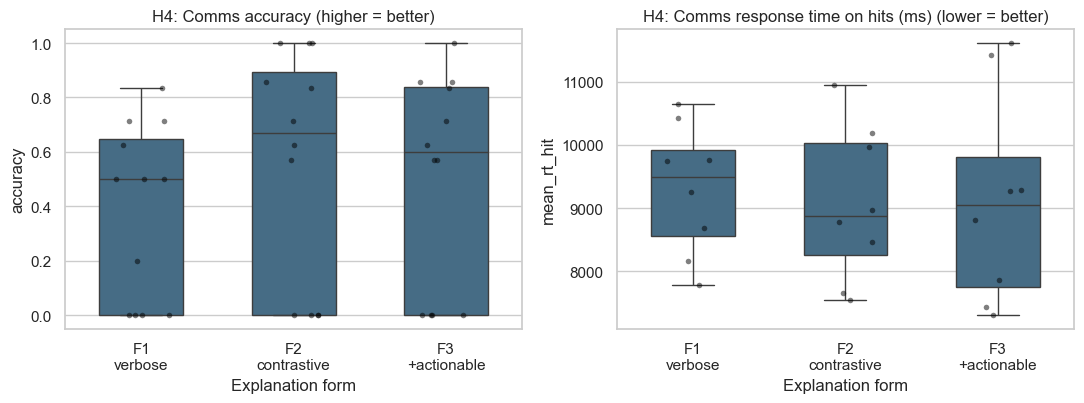

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, col, title, better in zip(
    axes,
    ["accuracy", "mean_rt_hit"],
    ["Comms accuracy", "Comms response time on hits (ms)"],
    ["higher = better", "lower = better"],
):
    sns.boxplot(data=table, x="form", y=col, order=FORM_ORDER,
                color="#3b6e8f", width=0.55, ax=ax)
    sns.stripplot(data=table, x="form", y=col, order=FORM_ORDER,
                  color="black", alpha=0.5, size=4, jitter=0.18, ax=ax)
    ax.set_xlabel("Explanation form")
    ax.set_xticks(range(len(FORM_ORDER)))
    ax.set_xticklabels([FORM_LABELS[f] for f in FORM_ORDER])
    ax.set_title(f"H4: {title} ({better})")
fig.tight_layout()
fig.savefig(OUT / "h4_comms_by_form.png", dpi=150)
plt.show()

## 4. Within-subject view

Each grey line is one participant across the three forms; the thick line is the
mean. Because the design is within-subjects, this shows whether *individuals* tend
to improve from F1 to F2/F3, not just the group average. Shown for the two
headline measures (resman RMSD, comms accuracy).

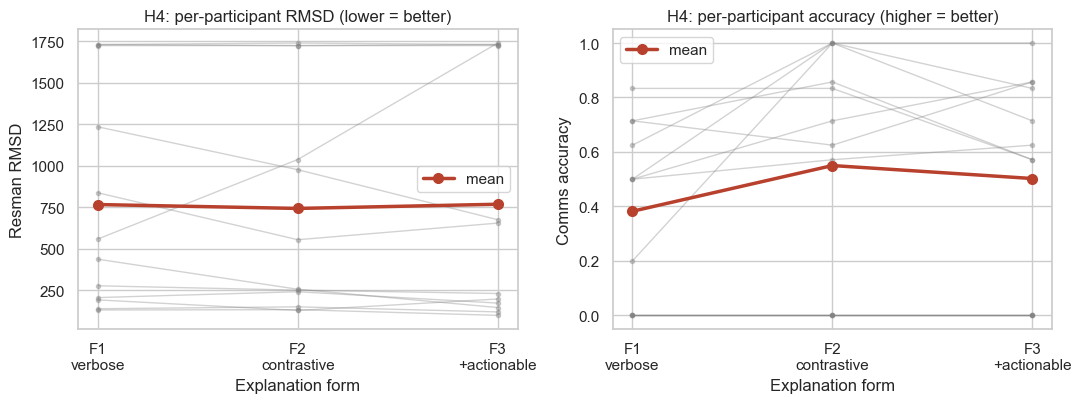

In [8]:
def perparticipant_panel(ax, col, ylabel, title):
    wide = table.pivot_table(index="participant", columns="form", values=col)
    wide = wide.reindex(columns=FORM_ORDER)
    x = np.arange(len(FORM_ORDER))
    for _, row in wide.iterrows():
        ax.plot(x, row.values, color="grey", alpha=0.35, marker="o",
                markersize=3, linewidth=1)
    ax.plot(x, wide.mean(axis=0).values, color="#b8412e", marker="o",
            markersize=7, linewidth=2.5, label="mean")
    ax.set_xticks(x)
    ax.set_xticklabels([FORM_LABELS[f] for f in FORM_ORDER])
    ax.set_xlabel("Explanation form")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
perparticipant_panel(axes[0], "rmsd_mean", "Resman RMSD",
                     "H4: per-participant RMSD (lower = better)")
perparticipant_panel(axes[1], "accuracy", "Comms accuracy",
                     "H4: per-participant accuracy (higher = better)")
fig.tight_layout()
fig.savefig(OUT / "h4_perparticipant.png", dpi=150)
plt.show()

## 5. Compact summary table

The four reported H4 measures — two per non-aided task — summarised per form with
**mean, median and standard deviation**. H4 predicts F2/F3 to beat F1: higher
*% in tolerance* and *accuracy*, lower *RMSD* and *response time*.

In [9]:
REPORT_COLS = ["rmsd_mean", "pct_in_tolerance_mean", "accuracy", "mean_rt_hit"]
summary = (table.groupby("form")[REPORT_COLS]
              .agg(["mean", "median", "std"])
              .reindex(FORM_ORDER)
              .round(2))
summary.to_csv(OUT / "h4_nonaided_summary_by_form.csv")  # machine-readable names
summary.rename(columns=COL_LABELS)

RMSD from target [units] (down = better)                  \
                                         mean  median     std   
form                                                            
F1                                     767.51  499.08  662.63   
F2                                     744.06  406.46  669.08   
F3                                     769.29  443.67  735.62   

     Time in tolerance [%] (up = better)                \
                                    mean median    std   
form                                                     
F1                                 44.30  38.83  35.51   
F2                                 46.58  45.28  37.36   
F3                                 50.03  50.67  39.44   

     Accuracy [hits / signal trials] (up = better)               \
                                              mean median   std   
form                                                              
F1                                            0.38   0.50  0.32   
F2                                            0.55   0.67  0.43   
F3                                            0.50   0.60  0.39   

     Response time on hits [ms] (down = better)                    
                                           mean   median      std  
form                                                               
F1                                      9304.00  9494.00  1031.95  
F2                                      9064.50  8878.00  1218.41  
F3                                      9124.17  9041.33  1664.92

## 6. Composite performance index

The four measures above answer H4 one task at a time. To get a **single number per
block** that summarises overall non-aided performance, we combine them into a
standardised composite. Three steps are needed because the measures differ in
unit, scale and direction:

1. **Orient** every measure so that *higher = better* (RMSD and response time are
   multiplied by −1).
2. **Standardise** each measure to a z-score so that, regardless of its original
   unit, it contributes on the same scale.
3. **Average** the four z-scores into one *Performance Index* per block (higher =
   better overall performance). Equal weighting is the deliberate, neutral choice;
   we are not asserting that one task matters more than another.

`WITHIN_PARTICIPANT = True` standardises each measure *within* participant (each
person as their own baseline), which removes between-person level differences and
suits the within-subjects design once N grows. At the current pilot N it is
equivalent to pooled standardisation.

> **Caveat.** The composite is a *summary*, not a replacement for the per-measure
> tables: a single index can hide a speed–accuracy trade-off or an improvement in
> one task masking a decline in another.

In [10]:
WITHIN_PARTICIPANT = True
# direction: +1 if higher is better, -1 if lower is better
INDEX_DIRECTION = {"rmsd_mean": -1, "pct_in_tolerance_mean": +1,
                   "accuracy": +1, "mean_rt_hit": -1}

def zscore(s):
    sd = s.std(ddof=0)
    return (s - s.mean()) / sd if sd and np.isfinite(sd) else s * 0.0

comp = table.copy()
z_cols = []
for col, direction in INDEX_DIRECTION.items():
    oriented = comp[col] * direction
    if WITHIN_PARTICIPANT:
        z = oriented.groupby(comp["participant"]).transform(zscore)
    else:
        z = zscore(oriented)
    zc = f"z_{col}"
    comp[zc] = z
    z_cols.append(zc)

comp["performance_index"] = comp[z_cols].mean(axis=1)

idx_desc = (comp.groupby("form")["performance_index"]
                .agg(["mean", "median", "std"])
                .reindex(FORM_ORDER)
                .round(3))
print(f"Composite of {list(INDEX_DIRECTION)} "
      f"(within-participant z = {WITHIN_PARTICIPANT}); higher = better.")
idx_desc

Composite of ['rmsd_mean', 'pct_in_tolerance_mean', 'accuracy', 'mean_rt_hit'] (within-participant z = True); higher = better.


,mean,median,std
form,,,
F1,-0.299,-0.306,0.611
F2,0.021,-0.029,0.551
F3,0.278,0.418,0.642


**Figure 5 — composite performance index by form.** Box = median and IQR; each
dot is one block. H4 predicts the F2/F3 distributions to sit **above** F1.

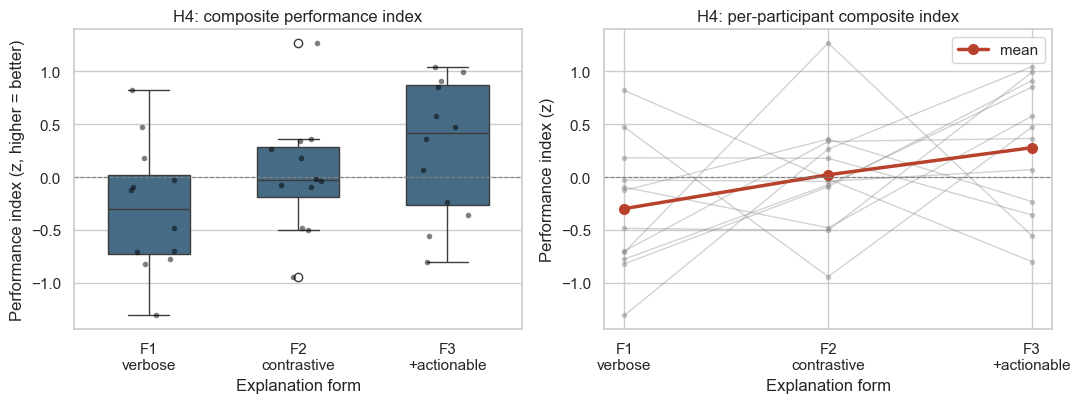

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

sns.boxplot(data=comp, x="form", y="performance_index", order=FORM_ORDER,
            color="#3b6e8f", width=0.55, ax=axes[0])
sns.stripplot(data=comp, x="form", y="performance_index", order=FORM_ORDER,
              color="black", alpha=0.5, size=4, jitter=0.18, ax=axes[0])
axes[0].axhline(0, color="grey", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("Explanation form")
axes[0].set_ylabel("Performance index (z, higher = better)")
axes[0].set_xticks(range(len(FORM_ORDER)))
axes[0].set_xticklabels([FORM_LABELS[f] for f in FORM_ORDER])
axes[0].set_title("H4: composite performance index")

wide = comp.pivot_table(index="participant", columns="form",
                        values="performance_index").reindex(columns=FORM_ORDER)
x = np.arange(len(FORM_ORDER))
for _, row in wide.iterrows():
    axes[1].plot(x, row.values, color="grey", alpha=0.35, marker="o",
                 markersize=3, linewidth=1)
axes[1].plot(x, wide.mean(axis=0).values, color="#b8412e", marker="o",
             markersize=7, linewidth=2.5, label="mean")
axes[1].axhline(0, color="grey", linewidth=0.8, linestyle="--")
axes[1].set_xticks(x)
axes[1].set_xticklabels([FORM_LABELS[f] for f in FORM_ORDER])
axes[1].set_xlabel("Explanation form")
axes[1].set_ylabel("Performance index (z)")
axes[1].set_title("H4: per-participant composite index")
axes[1].legend()

fig.tight_layout()
fig.savefig(OUT / "h4_composite_index_by_form.png", dpi=150)
plt.show()

comp[["participant", "form", "block", "performance_index"]].to_csv(
    OUT / "h4_composite_index.csv", index=False)